In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')


# Iris Flower Classification Project

This notebook demonstrates a simple machine learning workflow to classify iris flower species using the Iris dataset. It covers data loading, exploratory analysis, model training, evaluation, and prediction visualization.

## Objective
- Build a classifier to predict the species of an iris flower.
- Evaluate the model using standard classification metrics.
- Present the results in a clear and professional format 


In [24]:
df = pd.read_csv('Iris.csv')
print('Dataset shape:', df.shape)
print('\nColumns in the dataset:')
print(df.columns.tolist())
print('\nFirst 5 rows of the dataset:')
df.head()

Dataset shape: (150, 6)

Columns in the dataset:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

First 5 rows of the dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Data Preparation

The dataset contains the flower measurements and the target label, Species. The Id column is removed because it does not contribute to the prediction task.

In [25]:
X = df.drop(columns=['Id', 'Species'])
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])
print('Class distribution in training set:')
print(y_train.value_counts().sort_index())

Training set size: 120
Testing set size: 30
Class distribution in training set:
Species
Iris-setosa        40
Iris-versicolor    40
Iris-virginica     40
Name: count, dtype: int64


In [15]:
X_train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3


In [16]:
print('Class distribution in training set:')
y_train.value_counts().sort_index()

Class distribution in training set:


Species
Iris-setosa        40
Iris-versicolor    40
Iris-virginica     40
Name: count, dtype: int64

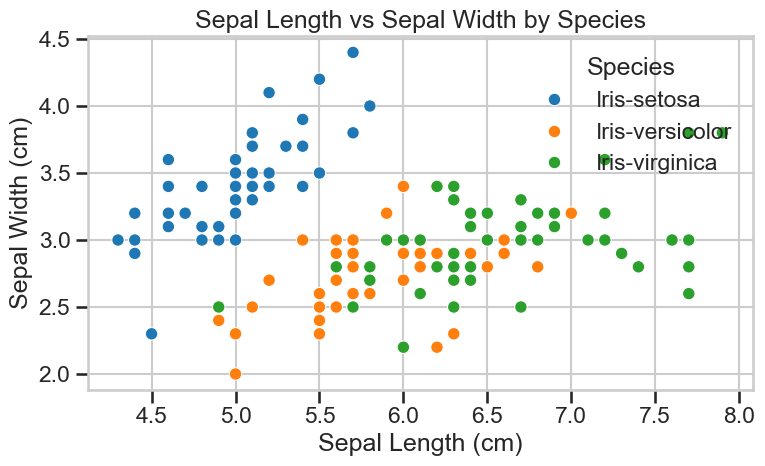

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='SepalLengthCm', y='SepalWidthCm', hue='Species', s=80)
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

## Model Training

A Random Forest Classifier is used because it performs well on structured tabular data and is robust to overfitting compared with a single decision tree.

In [26]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Model trained successfully.')
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Model trained successfully.

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



In [27]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.2%}')

Accuracy Score: 90.00%


In [20]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


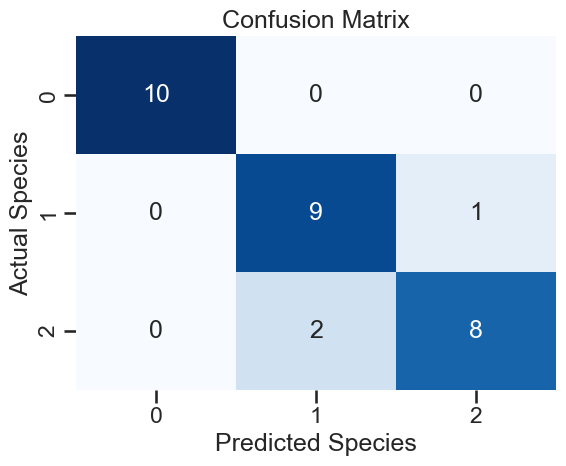

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.tight_layout()
plt.show()

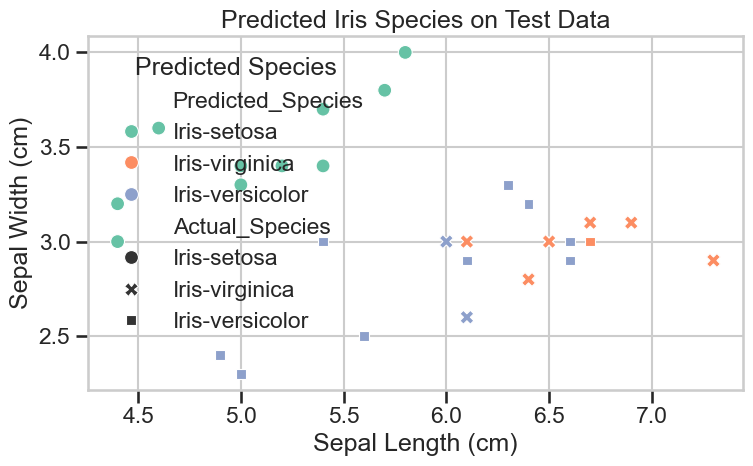

In [22]:
pred_df = X_test.copy()
pred_df['Actual_Species'] = y_test.values
pred_df['Predicted_Species'] = y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=pred_df,
    x='SepalLengthCm',
    y='SepalWidthCm',
    hue='Predicted_Species',
    style='Actual_Species',
    s=100,
    palette='Set2'
)
plt.title('Predicted Iris Species on Test Data')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Predicted Species')
plt.tight_layout()
plt.show()

## Conclusion

This project shows how a machine learning model can classify iris flower species using basic measurements such as petal and sepal length/width. The Random Forest model produced strong results and demonstrates a complete end-to-end classification workflow that is suitable for an internship presentation.

### Summary
- Dataset used: Iris dataset
- Algorithm used: Random Forest Classifier
- Main evaluation metric: Accuracy
- Outcome: Reliable species prediction on test data
